# ResNet50 Transfer Learning for Plant Disease Classification
This notebook trains a ResNet50-based model using `train/` and `val/` folders. It then predicts validation images and displays actual versus predicted labels.

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
# from tensorflow.keras.preprocessing.image import ImageDataGenerator, image
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs:', gpus if gpus else 'No GPU detected')

TensorFlow version: 2.21.0
GPUs: No GPU detected


In [9]:
base_dir = os.getcwd()
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

print('Train directory:', train_dir)
print('Validation directory:', val_dir)

Train directory: /home/swayam/SWAYAM/KrishiScan/split_data/train
Validation directory: /home/swayam/SWAYAM/KrishiScan/split_data/val


In [10]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator, image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image


batch_size = 16
img_size = (224, 224)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

class_indices = train_generator.class_indices
print('Number of classes:', len(class_indices))
print('Class indices:', class_indices)

Found 40441 images belonging to 33 classes.
Found 4942 images belonging to 33 classes.
Number of classes: 33
Class indices: {'Corn_(maize)_Cercospora_leaf_spot': 0, 'Corn_(maize)_Common_rust_': 1, 'Corn_(maize)_Northern_Leaf_Blight': 2, 'Corn_(maize)_healthy': 3, 'Potato___Early_blight': 4, 'Potato___Late_blight': 5, 'Potato___healthy': 6, 'Rice Blight': 7, 'Rice Brown Spot': 8, 'Rice Healthy': 9, 'Rice Leaf Blast': 10, 'SugarCane Healthy ': 11, 'SugarCane Mosaic ': 12, 'SugarCane RedRot ': 13, 'SugarCane Rust ': 14, 'SugarCane Yellow Leaf ': 15, 'Tomato___Bacterial_spot': 16, 'Tomato___Early_blight': 17, 'Tomato___Late_blight': 18, 'Tomato___Leaf_Mold': 19, 'Tomato___Septoria_leaf_spot': 20, 'Tomato___Spider_mites Two-spotted_spider_mite': 21, 'Tomato___Target_Spot': 22, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 23, 'Tomato___Tomato_mosaic_virus': 24, 'Tomato___healthy': 25, 'Wheat Brown leaf Rust': 26, 'Wheat Healthy': 27, 'Wheat Septoria': 28, 'Wheat black rust': 29, 'Wheat leaf bli

In [11]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,653,729 (94.05 MB)

 Trainable params: 1,066,017 (4.07 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [12]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint('resnet50_transfer_best.h5', save_best_only=True, monitor='val_loss')
]

epochs = 20
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/20
2528/2528 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5648 - loss: 1.5076

2528/2528 ━━━━━━━━━━━━━━━━━━━━ 3158s 1s/step - accuracy: 0.7100 - loss: 0.9465 - val_accuracy: 0.8752 - val_loss: 0.3904 - learning_rate: 1.0000e-04
Epoch 2/20
2528/2528 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8458 - loss: 0.4690

2528/2528 ━━━━━━━━━━━━━━━━━━━━ 3162s 1s/step - accuracy: 0.8559 - loss: 0.4337 - val_accuracy: 0.8986 - val_loss: 0.2977 - learning_rate: 1.0000e-04
Epoch 3/20
2528/2528 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8870 - loss: 0.3335

2528/2528 ━━━━━━━━━━━━━━━━━━━━ 3435s 1s/step - accuracy: 0.8917 - loss: 0.3240 - val_accuracy: 0.9108 - val_loss: 0.2633 - learning_rate: 1.0000e-04
Epoch 4/20
2528/2528 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9050 - loss: 0.2772

2528/2528 ━━━━━━━━━━━━━━━━━━━━ 2995s 1s/step - accuracy: 0.9066 - loss: 0.2723 - val_accuracy: 0.9132 - val_loss: 0.2458 - learning_rate: 1.0000e-04
Epoch 5/20
2528/2528 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9145 - loss: 0.2460

2528/2528 ━━━━━━━━━━━━━━━━━━━━ 2992s 1s/step - accuracy: 0.9183 - loss: 0.2368 - val_accuracy: 0.9298 - val_loss: 0.2132 - learning_rate: 1.0000e-04
Epoch 6/20
2528/2528 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9279 - loss: 0.2120

2528/2528 ━━━━━━━━━━━━━━━━━━━━ 2993s 1s/step - accuracy: 0.9262 - loss: 0.2123 - val_accuracy: 0.9276 - val_loss: 0.2116 - learning_rate: 1.0000e-04
Epoch 7/20
  14/2528 ━━━━━━━━━━━━━━━━━━━━ 49:47 1s/step - accuracy: 0.9347 - loss: 0.1855

KeyboardInterrupt: 

In [ ]:
from PIL import Image
import os
from pathlib import Path

def find_corrupted_images(directory):
    """Scan directory recursively for corrupted images"""
    corrupted = []
    total = 0
    
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                filepath = os.path.join(root, file)
                total += 1
                try:
                    img = Image.open(filepath)
                    img.verify()
                except (OSError, IOError) as e:
                    corrupted.append((filepath, str(e)))
    
    return corrupted, total

# Scan all directories
print("Scanning for corrupted images...")
train_corrupted, train_total = find_corrupted_images(train_dir)
val_corrupted, val_total = find_corrupted_images(val_dir)

print(f"\nTrain: {len(train_corrupted)} corrupted out of {train_total}")
print(f"Val: {len(val_corrupted)} corrupted out of {val_total}")

# Remove corrupted images
def remove_corrupted(corrupted_list):
    for filepath, error in corrupted_list:
        try:
            os.remove(filepath)
            print(f"Removed: {filepath}")
        except Exception as e:
            print(f"Failed to remove {filepath}: {e}")

if train_corrupted or val_corrupted:
    print("\nRemoving corrupted images...")
    remove_corrupted(train_corrupted)
    remove_corrupted(val_corrupted)
    print("Cleanup complete!")
else:
    print("No corrupted images found.")


Scanning for corrupted images...

Train: 2 corrupted out of 40443
Val: 0 corrupted out of 4942

Removing corrupted images...
Removed: /home/swayam/SWAYAM/KrishiScan/split_data/train/Wheat black rust/Wheat_Black_Rust_106_hflip.png
Removed: /home/swayam/SWAYAM/KrishiScan/split_data/train/Wheat black rust/Wheat_Black_Rust_547_hflip_vflip.png
Cleanup complete!


NameError: name 'history' is not defined

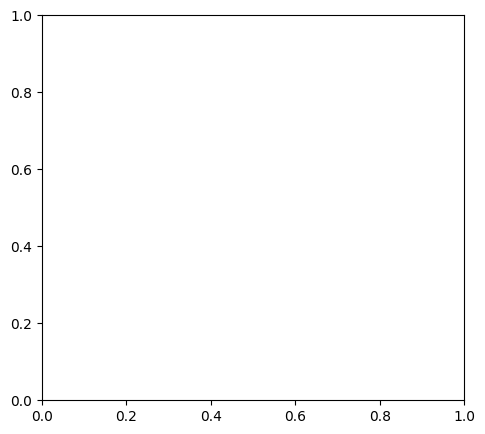

In [14]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

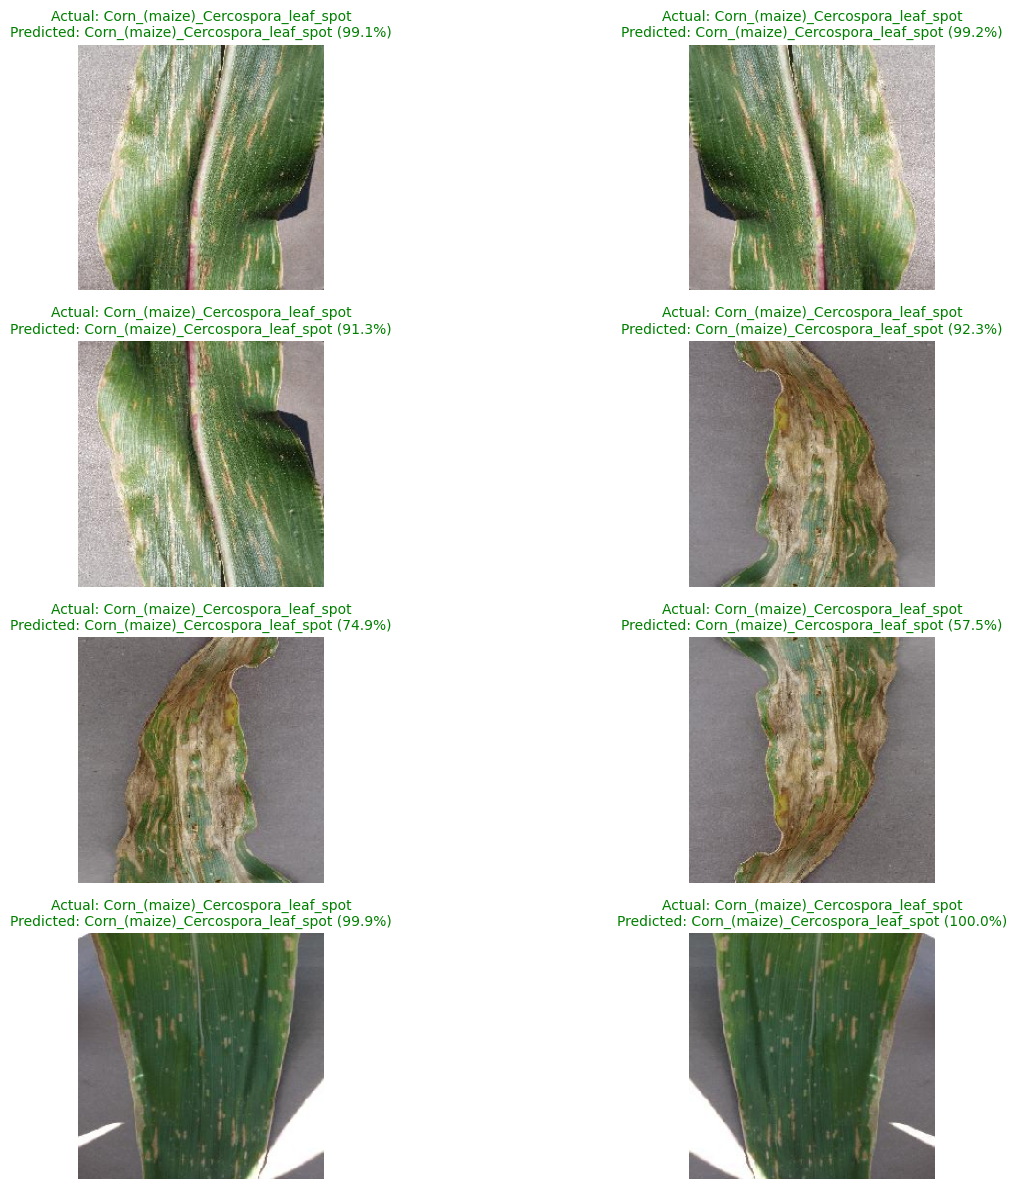

In [15]:
inv_class_indices = {v: k for k, v in class_indices.items()}
sample_count = min(8, len(val_generator.filepaths))

plt.figure(figsize=(16, 12))
for i in range(sample_count):
    img_path = val_generator.filepaths[i]
    actual_label = inv_class_indices[val_generator.classes[i]]
    img = image.load_img(img_path, target_size=img_size)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    pred = model.predict(x, verbose=0)[0]
    pred_index = np.argmax(pred)
    pred_label = inv_class_indices[pred_index]
    confidence = float(np.max(pred) * 100)

    ax = plt.subplot(4, 2, i + 1)
    ax.imshow(img)
    ax.set_title(
        f'Actual: {actual_label}\nPredicted: {pred_label} ({confidence:.1f}%)',
        color='green' if actual_label == pred_label else 'red',
        fontsize=10
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

In [16]:
print('Sample validation predictions:')
print('{:<3} {:<45} {:<45} {:>10}'.format('No.', 'Actual', 'Predicted', 'Confidence'))
print('-' * 110)
for i in range(sample_count):
    img_path = val_generator.filepaths[i]
    actual_label = inv_class_indices[val_generator.classes[i]]
    img = image.load_img(img_path, target_size=img_size)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    pred = model.predict(x, verbose=0)[0]
    pred_index = np.argmax(pred)
    pred_label = inv_class_indices[pred_index]
    confidence = float(np.max(pred) * 100)
    print('{:<3} {:<45} {:<45} {:>9.1f}%'.format(i + 1, actual_label, pred_label, confidence))

Sample validation predictions:
No. Actual                                        Predicted                                     Confidence
--------------------------------------------------------------------------------------------------------------
1   Corn_(maize)_Cercospora_leaf_spot             Corn_(maize)_Cercospora_leaf_spot                  99.1%
2   Corn_(maize)_Cercospora_leaf_spot             Corn_(maize)_Cercospora_leaf_spot                  99.2%
3   Corn_(maize)_Cercospora_leaf_spot             Corn_(maize)_Cercospora_leaf_spot                  91.3%
4   Corn_(maize)_Cercospora_leaf_spot             Corn_(maize)_Cercospora_leaf_spot                  92.3%
5   Corn_(maize)_Cercospora_leaf_spot             Corn_(maize)_Cercospora_leaf_spot                  74.9%
6   Corn_(maize)_Cercospora_leaf_spot             Corn_(maize)_Cercospora_leaf_spot                  57.5%
7   Corn_(maize)_Cercospora_leaf_spot             Corn_(maize)_Cercospora_leaf_spot                  99.9%
8 

In [18]:
# Load the best saved model and test on all images in test folder
from tensorflow.keras.models import load_model
import pandas as pd

# Load the saved model
print("Loading saved model: resnet50_transfer_best.h5")
best_model = load_model('resnet50_transfer_best.h5')

# Set up test directory
test_dir = os.path.join(base_dir, 'test')

# Create test data generator (no augmentation for testing)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Important: keep order for evaluation
)

# Evaluate model on test set
print("\nEvaluating model on test set...")
test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Get predictions for all test images
print("\nGenerating predictions for all test images...")
predictions = best_model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

# Create results DataFrame
results_df = pd.DataFrame({
    'filepath': test_generator.filepaths,
    'true_class': true_classes,
    'predicted_class': predicted_classes,
    'true_label': [inv_class_indices[cls] for cls in true_classes],
    'predicted_label': [inv_class_indices[cls] for cls in predicted_classes],
    'confidence': np.max(predictions, axis=1) * 100
})

# Add correctness column
results_df['correct'] = results_df['true_class'] == results_df['predicted_class']

# Summary statistics
total_images = len(results_df)
correct_predictions = results_df['correct'].sum()
incorrect_predictions = total_images - correct_predictions

print(f"\n{'='*60}")
print("TEST RESULTS SUMMARY")
print(f"{'='*60}")
print(f"Total test images: {total_images}")
print(f"Correct predictions: {correct_predictions} ({correct_predictions/total_images*100:.2f}%)")
print(f"Incorrect predictions: {incorrect_predictions} ({incorrect_predictions/total_images*100:.2f}%)")

# Show per-class accuracy
print(f"\n{'='*60}")
print("PER-CLASS ACCURACY")
print(f"{'='*60}")
class_accuracy = results_df.groupby('true_label').agg({
    'correct': ['count', 'sum', lambda x: x.sum()/x.count()*100]
}).round(2)
class_accuracy.columns = ['Total', 'Correct', 'Accuracy (%)']
class_accuracy = class_accuracy.sort_values('Accuracy (%)', ascending=False)
print(class_accuracy.to_string())

# Show some examples of incorrect predictions
incorrect_df = results_df[~results_df['correct']].head(10)
if len(incorrect_df) > 0:
    print(f"\n{'='*60}")
    print("EXAMPLES OF INCORRECT PREDICTIONS")
    print(f"{'='*60}")
    for idx, row in incorrect_df.iterrows():
        print(f"File: {os.path.basename(row['filepath'])}")
        print(f"True: {row['true_label']} | Predicted: {row['predicted_label']} ({row['confidence']:.1f}%)")
        print("-" * 60)

print(f"\n{'='*60}")
print("TEST EVALUATION COMPLETE")
print(f"{'='*60}")
print(f"Model file: resnet50_transfer_best.h5")
print(f"Test accuracy: {test_accuracy*100:.2f}%")
print(f"Total images tested: {total_images}")

Loading saved model: resnet50_transfer_best.h5


Found 3983 images belonging to 33 classes.

Evaluating model on test set...
249/249 ━━━━━━━━━━━━━━━━━━━━ 236s 941ms/step - accuracy: 0.9322 - loss: 0.1925

Test Loss: 0.1925
Test Accuracy: 0.9322 (93.22%)

Generating predictions for all test images...
249/249 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step

TEST RESULTS SUMMARY
Total test images: 3983
Correct predictions: 3713 (93.22%)
Incorrect predictions: 270 (6.78%)

PER-CLASS ACCURACY
                                               Total  Correct  Accuracy (%)
true_label                                                                 
Corn_(maize)_Cercospora_leaf_spot                 52       52        100.00
Corn_(maize)_Common_rust_                        120      120        100.00
Rice Brown Spot                                  164      164        100.00
Rice Blight                                      163      163        100.00
Rice Healthy                                     150      150        100.00
Tomato___healthy                      